In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

In [77]:
data = pd.read_csv("paysim.csv")
df=pd.DataFrame(data)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [79]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [80]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [81]:
df['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


Text(0.5, 1.0, '1 Fraud                         0 non-Fraud')

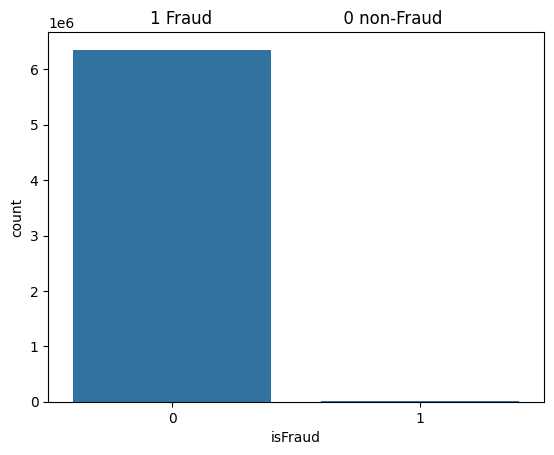

In [84]:
sns.countplot(df,x='isFraud')
plt.title("1 Fraud                         0 non-Fraud")

Text(0.5, 1.0, 'Frequencies of transaction types')

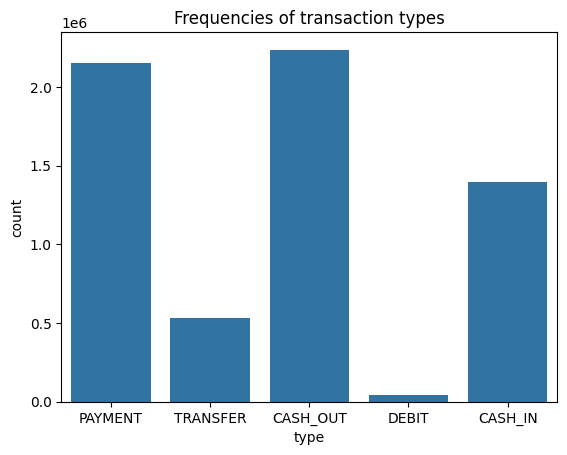

In [85]:
sns.countplot(df,x='type')
plt.title("Frequencies of transaction types")

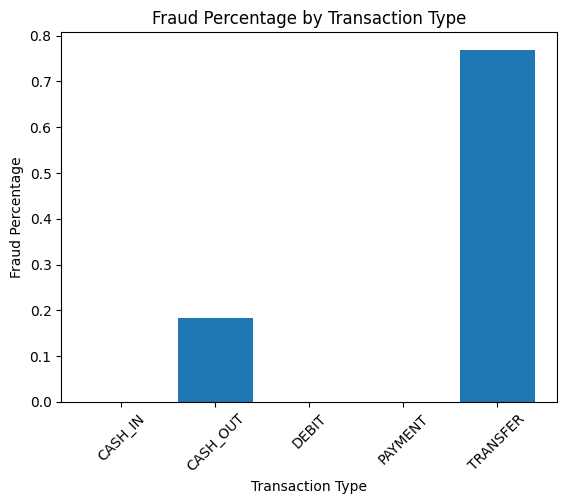

In [86]:
# Group by "TransactionType" and calculate the mean of "isFraud"
fraud_percentage_by_type = df.groupby('type')['isFraud'].mean() * 100
# Create a bar plot
plt.bar(fraud_percentage_by_type.index, fraud_percentage_by_type.values)
# Adding labels and title
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Percentage')
plt.title('Fraud Percentage by Transaction Type')

# Rotate x labels for better readability
plt.xticks(rotation=45)

# Display the plot
#plt.tight_layout()
plt.show()

In [87]:
data = df.loc[df['type'].isin(['CASH_OUT', 'TRANSFER'])]
print('The new data now has ', len(data), ' transactions.')

The new data now has  2770409  transactions.


In [88]:
print('Number of transactions where the transaction amount is negative: ' +
str(sum(data['amount'] < 0)))

Number of transactions where the transaction amount is negative: 0


In [89]:
print('Number of transactions where the transaction amount is equal to zero: ' +
str(sum(data['amount'] == 0)))

Number of transactions where the transaction amount is equal to zero: 16


Percentage of transactions where originators initial balance is 0: 47.23


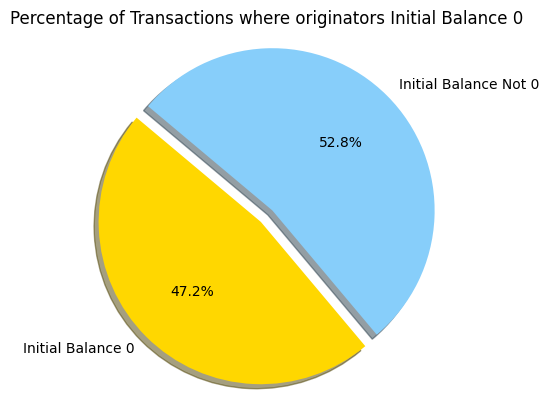

In [90]:
no_Ofzero=sum(data['oldbalanceOrg']==0)
total=len(data['oldbalanceDest'])
percentage=(no_Ofzero/total)*100
print(f"Percentage of transactions where originators initial balance is 0: {percentage:.2f}")


labels = ['Initial Balance 0', 'Initial Balance Not 0']
sizes = [percentage, 100 - percentage]
colors = ['gold', 'lightskyblue']
explode = (0.1, 0)  # explode the 1st slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Percentage of Transactions where originators Initial Balance 0")
plt.show()

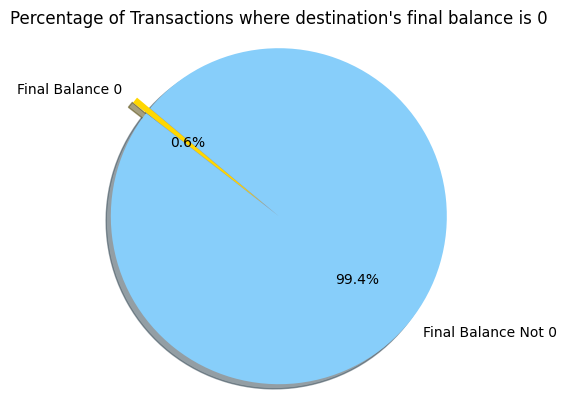

In [59]:
no_Ofzero=sum(data['newbalanceDest']==0)
total=len(data['newbalanceDest'])
percentage=(no_Ofzero/total)*100
#print(f"Percentage of transactions where  destination's final balance is 0:{percantage:.2f}")

#pie plot
import matplotlib.pyplot as plt

# Data
labels = ['Final Balance 0', 'Final Balance Not 0']
sizes = [percentage, 100 - percentage]  # Corrected calculation
colors = ['gold', 'lightskyblue']
explode = (0.1, 0)  # Explode the first slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Transactions where destination's final balance is 0")

# Display the plot
plt.show()

% transactions where originator balances are not accurately captured:93.72 


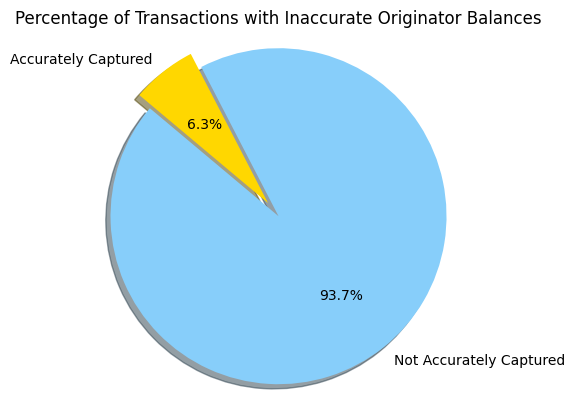

In [60]:
tolerance = 1e-6
not_accuratly_captured=sum(np.abs(data['oldbalanceOrg']-data['amount']==data['newbalanceOrig'])<tolerance)
total=len(data['newbalanceOrig'])
percentage=(not_accuratly_captured/total)*100
print(f"% transactions where originator balances are not accurately captured:{percentage:.2f} ")


labels = [ 'Not Accurately Captured','Accurately Captured']
sizes = [percentage,100 - percentage ]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Not Accurately Captured" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Transactions with Inaccurate Originator Balances")

# Display the plot
plt.show()

% transactions where destination's balances are not accurately captured:42.09 


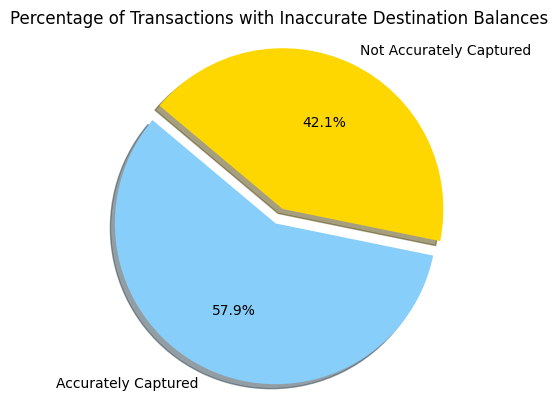

In [61]:
tolerance = 1e-6
not_accuratly_captured=sum(np.abs(data['amount']+data['oldbalanceDest']==data['newbalanceDest'])<tolerance)
total=len(data['newbalanceDest'])
percentage=(not_accuratly_captured/total)*100
print(f"% transactions where destination's balances are not accurately captured:{percentage:.2f} ")


# Data for the pie plot
labels = ["Accurately Captured", "Not Accurately Captured"]
sizes = [100 - percentage, percentage]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Not Accurately Captured" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Transactions with Inaccurate Destination Balances")

# Display the plot
plt.show()

8213
41
% of fraudulent transactions where initial balance of originator is 0: 0.499209


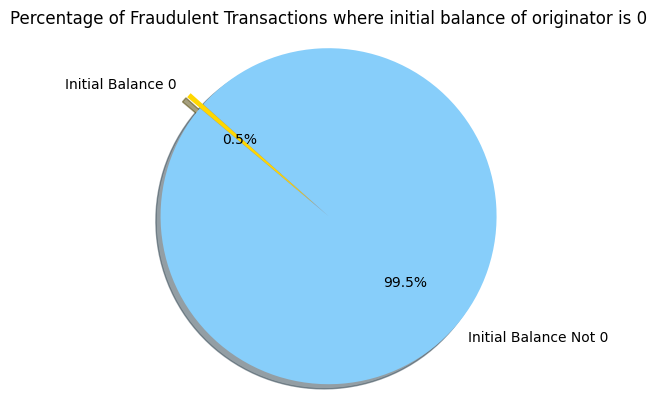

In [91]:
#for fraudulant data

fraud_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==1 :
    fraud_count=fraud_count+1
print(fraud_count)

value_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==1 and data['oldbalanceOrg'].values[i]==0 :
    value_count=value_count+1
print(value_count)


percentage=(value_count/fraud_count)*100
print(f"% of fraudulent transactions where initial balance of originator is 0: {percentage:2f}")

labels = ["Initial Balance Not 0", "Initial Balance 0"]
sizes = [100 - percentage, percentage]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Initial Balance 0" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Fraudulent Transactions where initial balance of originator is 0")

# Display the plot
plt.show()

2762196
1308541
% of non fraudulent transactions where initial balance of originator is 0: 47.373213


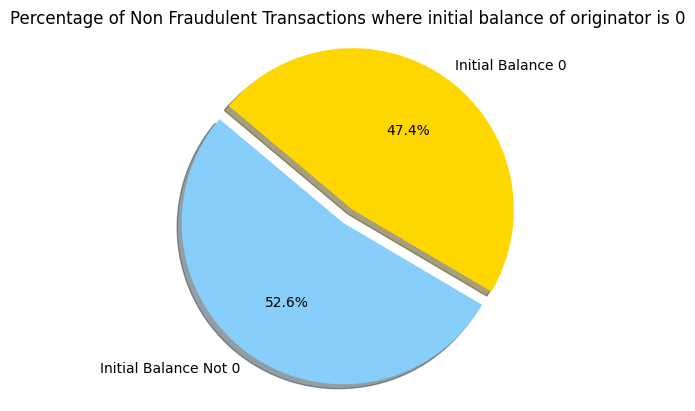

In [92]:
#for non fraudulant data

fraud_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==0 :
    fraud_count=fraud_count+1
print(fraud_count)

value_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==0 and data['oldbalanceOrg'].values[i]==0 :
    value_count=value_count+1
print(value_count)


percentage=(value_count/fraud_count)*100
print(f"% of non fraudulent transactions where initial balance of originator is 0: {percentage:2f}")

labels = ["Initial Balance Not 0", "Initial Balance 0"]
sizes = [100 - percentage, percentage]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Initial Balance 0" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.001f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Non Fraudulent Transactions where initial balance of originator is 0")

# Display the plot
plt.show()

In [93]:
data1 = data.drop(['nameOrig', 'nameDest','isFlaggedFraud','step'], axis=1)
print(data1.head())
len(data1)

        type     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
2   TRANSFER     181.00          181.0             0.0             0.0   
3   CASH_OUT     181.00          181.0             0.0         21182.0   
15  CASH_OUT  229133.94        15325.0             0.0          5083.0   
19  TRANSFER  215310.30          705.0             0.0         22425.0   
24  TRANSFER  311685.89        10835.0             0.0          6267.0   

    newbalanceDest  isFraud  
2             0.00        1  
3             0.00        1  
15        51513.44        0  
19            0.00        0  
24      2719172.89        0  


2770409

In [94]:
from sklearn.model_selection import train_test_split
train_data,test_data=train_test_split(data1,test_size=0.3,random_state=21)
print("len of train data",len(train_data))
print("len of test data",len(test_data))

len of train data 1939286
len of test data 831123


In [95]:
#training data
x_train=train_data.drop(["isFraud"],axis=1)
y_train=train_data["isFraud"]



#testing data
x_test=test_data.drop("isFraud",axis=1)
y_test=test_data["isFraud"]



print(type(y_train))

<class 'pandas.core.series.Series'>


In [96]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

#numerical features
num_feats=x_train.drop("type",axis=1)
num_feats_pipe=Pipeline([
    ("scalar",MinMaxScaler())
    ])
num_feats_preprocessed=num_feats_pipe.fit_transform(num_feats)

#catagorical features
cat_feats=x_train[["type"]]
cat_feats_pipe=Pipeline([
    ("encoder",OneHotEncoder())
    ])
cat_feats_preprocessed=cat_feats_pipe.fit_transform(cat_feats)
print(num_feats)

            amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
3864311   29390.09       14877.00            0.00            0.00   
3778961  154468.14       65988.00            0.00        71873.76   
6147088  284988.40       12351.00            0.00        39648.24   
4715397   32333.82           0.00            0.00       852397.79   
2427658   47606.16      107049.00        59442.84       367286.74   
...            ...            ...             ...             ...   
156780   777758.21      102466.00            0.00            0.00   
2573291  368448.02           0.00            0.00       605806.27   
1516393   90140.43           0.00            0.00       147255.11   
455773   575644.53      233100.02            0.00       854951.67   
4347167   68405.72           0.00            0.00        83057.26   

         newbalanceDest  
3864311        29390.09  
3778961       226341.90  
6147088       324636.64  
4715397       884731.61  
2427658       414892.91  
...            

In [97]:
from sklearn.compose import ColumnTransformer
num_list=list(num_feats)
cat_list=list(cat_feats)

final_pipeline=ColumnTransformer([
    ("num",num_feats_pipe,num_list),
    ("cat",cat_feats_pipe,cat_list)])
X_train_preprocessed=final_pipeline.fit_transform(x_train)
print(x_train)
X_train_preprocessed

X_test_preprocessed = final_pipeline.fit_transform(x_test)
X_test_preprocessed

             type     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
3864311  TRANSFER   29390.09       14877.00            0.00            0.00   
3778961  CASH_OUT  154468.14       65988.00            0.00        71873.76   
6147088  CASH_OUT  284988.40       12351.00            0.00        39648.24   
4715397  CASH_OUT   32333.82           0.00            0.00       852397.79   
2427658  CASH_OUT   47606.16      107049.00        59442.84       367286.74   
...           ...        ...            ...             ...             ...   
156780   TRANSFER  777758.21      102466.00            0.00            0.00   
2573291  CASH_OUT  368448.02           0.00            0.00       605806.27   
1516393  CASH_OUT   90140.43           0.00            0.00       147255.11   
455773   TRANSFER  575644.53      233100.02            0.00       854951.67   
4347167  CASH_OUT   68405.72           0.00            0.00        83057.26   

         newbalanceDest  
3864311        29390.09  

array([[3.36382277e-03, 3.67103538e-04, 0.00000000e+00, ...,
        1.55015961e-02, 1.00000000e+00, 0.00000000e+00],
       [2.78965548e-04, 1.57250330e-04, 0.00000000e+00, ...,
        6.04529651e-05, 1.00000000e+00, 0.00000000e+00],
       [7.93720827e-04, 0.00000000e+00, 0.00000000e+00, ...,
        1.00225831e-03, 1.00000000e+00, 0.00000000e+00],
       ...,
       [3.70686495e-02, 1.85933292e-04, 0.00000000e+00, ...,
        2.59405100e-02, 0.00000000e+00, 1.00000000e+00],
       [3.07404349e-03, 7.50537521e-04, 0.00000000e+00, ...,
        6.66157686e-04, 1.00000000e+00, 0.00000000e+00],
       [7.62723453e-04, 0.00000000e+00, 0.00000000e+00, ...,
        8.21207093e-04, 1.00000000e+00, 0.00000000e+00]])

In [105]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)

In [109]:
log_model=model.fit(X_train_preprocessed,y_train)

In [110]:
y_train_pred = log_model.predict(X_train_preprocessed)
y_train_pred

array([1, 0, 0, ..., 0, 1, 0])

In [111]:
y_test_pred=log_model.predict(X_test_preprocessed)
y_test_pred

array([0, 0, 0, ..., 0, 0, 0])

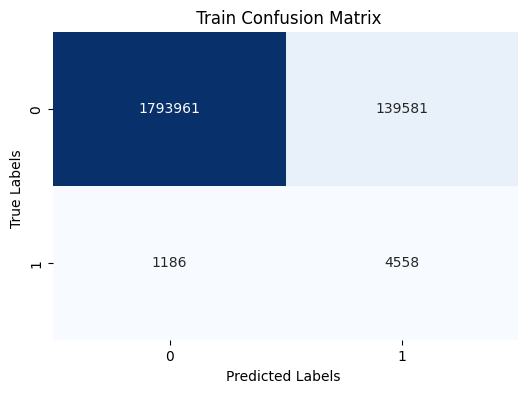

In [112]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Train Confusion Matrix")
plt.show()

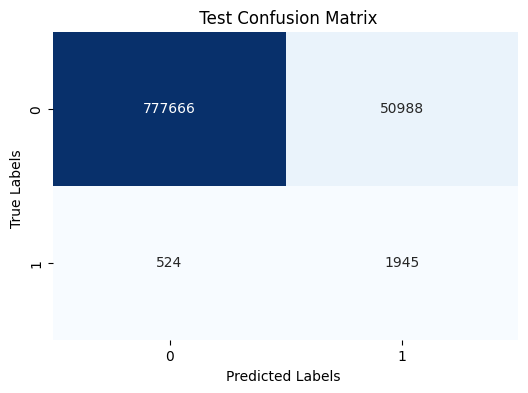

In [113]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Test Confusion Matrix")
plt.show()

In [114]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train,y_train_pred)
print("F1 Score of train data:", f1)

f2 = f1_score(y_test,y_test_pred)
print("F1 Score of test data:", f2)

F1 Score of train data: 0.060820773536691956
F1 Score of test data: 0.07021407169416266


In [115]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_preprocessed, y_train)

print('Shape of X_train_res:', X_train_res.shape)
print('Shape of y_train_res:', y_train_res.shape)
print('Class distribution after SMOTE:', y_train_res.value_counts())

Shape of X_train_res: (3867084, 7)
Shape of y_train_res: (3867084,)
Class distribution after SMOTE: isFraud
0    1933542
1    1933542
Name: count, dtype: int64


In [116]:
# Retrain the Logistic Regression model with SMOTE-treated data
log_model_smote = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
log_model_smote.fit(X_train_res, y_train_res)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

In [117]:
# Predict on training and test data with the SMOTE-trained model
y_train_pred_smote = log_model_smote.predict(X_train_res)
y_test_pred_smote = log_model_smote.predict(X_test_preprocessed)

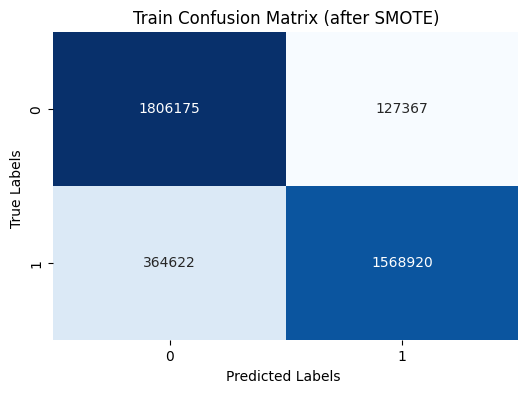

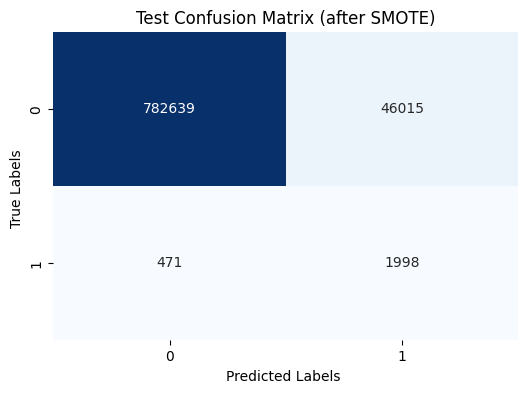

F1 Score of SMOTE-trained train data: 0.8644594552525753
F1 Score of SMOTE-trained test data: 0.07915692722158393


In [118]:
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train Confusion Matrix (after SMOTE)
cm_train_smote = confusion_matrix(y_train_res, y_train_pred_smote)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train_smote, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title("Train Confusion Matrix (after SMOTE)")
plt.show()

# Test Confusion Matrix (after SMOTE)
cm_test_smote = confusion_matrix(y_test, y_test_pred_smote)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_smote, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title("Test Confusion Matrix (after SMOTE)")
plt.show()

# F1-scores (after SMOTE)
f1_train_smote = f1_score(y_train_res, y_train_pred_smote)
print("F1 Score of SMOTE-trained train data:", f1_train_smote)

f1_test_smote = f1_score(y_test, y_test_pred_smote)
print("F1 Score of SMOTE-trained test data:", f1_test_smote)

In [123]:
y_test_prob_smote = log_model_smote.predict_proba(X_test_preprocessed)[:, 1]
print('First 5 probabilities:', y_test_prob_smote[:5])

First 5 probabilities: [0.07699801 0.25335135 0.21185826 0.15721174 0.14469493]


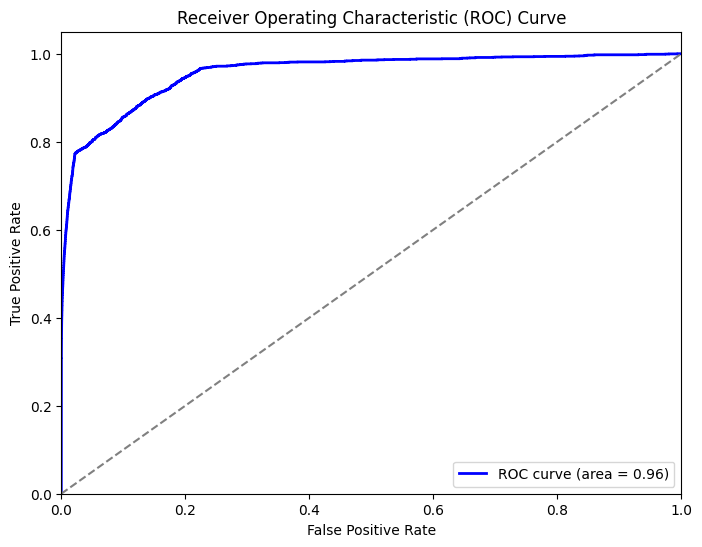

Optimal threshold (Youden's J): 0.3278
F1 Score at optimal threshold: 0.03740734793228476


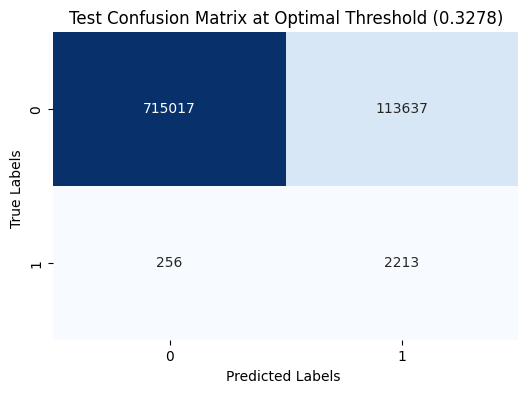

In [124]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
import numpy as np

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_smote)
roc_auc = roc_auc_score(y_test, y_test_prob_smote)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Find the optimal threshold using Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")

# Evaluate F1-score at this optimal threshold
y_test_pred_optimal = (y_test_prob_smote >= optimal_threshold).astype(int)
f1_test_optimal = f1_score(y_test, y_test_pred_optimal)
print("F1 Score at optimal threshold:", f1_test_optimal)

# Confusion matrix at optimal threshold
cm_test_optimal = confusion_matrix(y_test, y_test_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_optimal, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(f"Test Confusion Matrix at Optimal Threshold ({optimal_threshold:.4f})")
plt.show()

Optimal threshold for F1-score: 0.9719
F1 Score at optimal F1-threshold: 0.48619631901840493


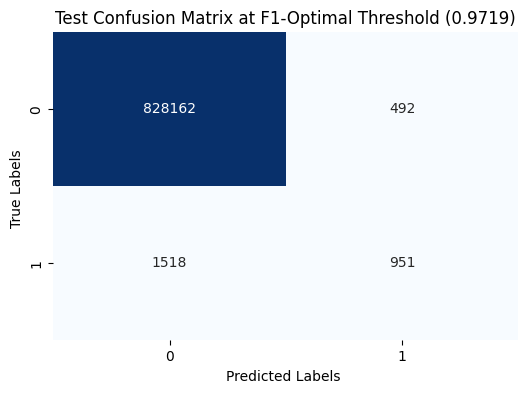

In [127]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Calculate precision and recall for different thresholds
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_prob_smote)

# Calculate F1-scores for all thresholds
f_scores = (2 * precision * recall) / (precision + recall)

# Find the optimal threshold that maximizes F1-score
optimal_idx_f1 = np.argmax(f_scores)
optimal_threshold_f1 = thresholds_pr[optimal_idx_f1]

print(f"Optimal threshold for F1-score: {optimal_threshold_f1:.4f}")

# Evaluate F1-score at this optimal threshold
y_test_pred_f1_optimal = (y_test_prob_smote >= optimal_threshold_f1).astype(int)
f1_test_f1_optimal = f1_score(y_test, y_test_pred_f1_optimal)
print("F1 Score at optimal F1-threshold:", f1_test_f1_optimal)

# Confusion matrix at optimal F1-threshold
cm_test_f1_optimal = confusion_matrix(y_test, y_test_pred_f1_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_f1_optimal, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(f"Test Confusion Matrix at F1-Optimal Threshold ({optimal_threshold_f1:.4f})")
plt.show()

Optimal threshold for F1-score: 0.9719
F1 Score at optimal F1-threshold: 0.48619631901840493


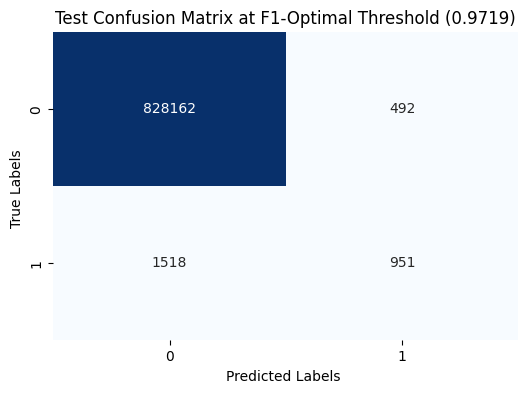

In [126]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Calculate precision and recall for different thresholds
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_prob_smote)

# Calculate F1-scores for all thresholds
f_scores = (2 * precision * recall) / (precision + recall)

# Find the optimal threshold that maximizes F1-score
optimal_idx_f1 = np.argmax(f_scores)
optimal_threshold_f1 = thresholds_pr[optimal_idx_f1]

print(f"Optimal threshold for F1-score: {optimal_threshold_f1:.4f}")

# Evaluate F1-score at this optimal threshold
y_test_pred_f1_optimal = (y_test_prob_smote >= optimal_threshold_f1).astype(int)
f1_test_f1_optimal = f1_score(y_test, y_test_pred_f1_optimal)
print("F1 Score at optimal F1-threshold:", f1_test_f1_optimal)

# Confusion matrix at optimal F1-threshold
cm_test_f1_optimal = confusion_matrix(y_test, y_test_pred_f1_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_f1_optimal, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(f"Test Confusion Matrix at F1-Optimal Threshold ({optimal_threshold_f1:.4f})")
plt.show()

Optimal threshold for F1-score: 0.9719
F1 Score at optimal F1-threshold: 0.48619631901840493


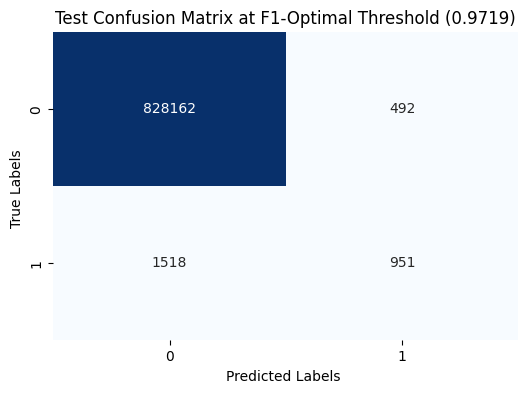

In [125]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Calculate precision and recall for different thresholds
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_prob_smote)

# Calculate F1-scores for all thresholds
f_scores = (2 * precision * recall) / (precision + recall)

# Find the optimal threshold that maximizes F1-score
optimal_idx_f1 = np.argmax(f_scores)
optimal_threshold_f1 = thresholds_pr[optimal_idx_f1]

print(f"Optimal threshold for F1-score: {optimal_threshold_f1:.4f}")

# Evaluate F1-score at this optimal threshold
y_test_pred_f1_optimal = (y_test_prob_smote >= optimal_threshold_f1).astype(int)
f1_test_f1_optimal = f1_score(y_test, y_test_pred_f1_optimal)
print("F1 Score at optimal F1-threshold:", f1_test_f1_optimal)

# Confusion matrix at optimal F1-threshold
cm_test_f1_optimal = confusion_matrix(y_test, y_test_pred_f1_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_f1_optimal, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(f"Test Confusion Matrix at F1-Optimal Threshold ({optimal_threshold_f1:.4f})")
plt.show()

In [119]:
y_test_prob_smote = log_model_smote.predict_proba(X_test_preprocessed)[:, 1]
print('First 5 probabilities:', y_test_prob_smote[:5])

First 5 probabilities: [0.07699801 0.25335135 0.21185826 0.15721174 0.14469493]


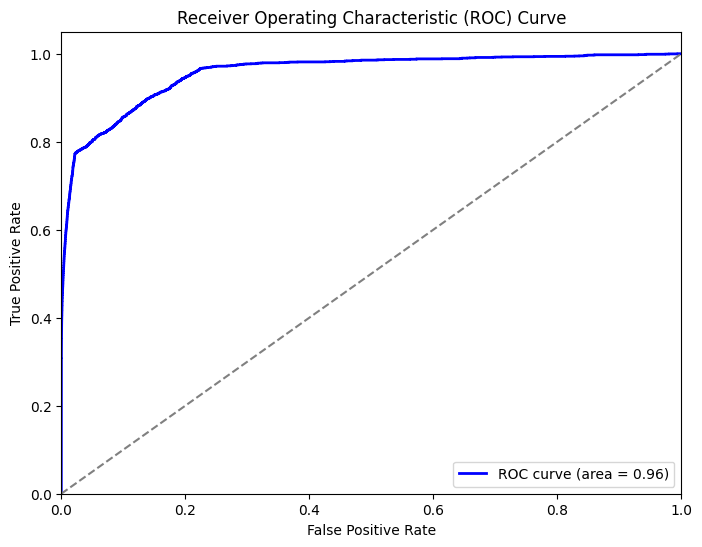

Optimal threshold (Youden's J): 0.3278
F1 Score at optimal threshold: 0.03740734793228476


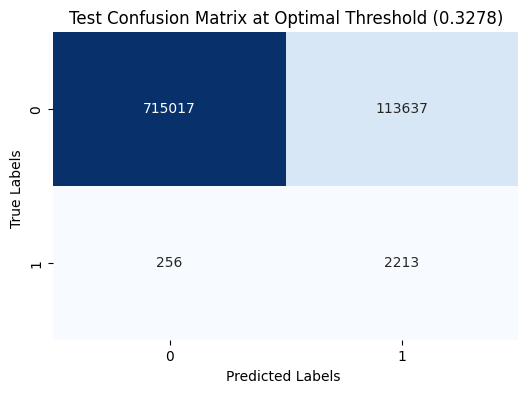

In [120]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
import numpy as np

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_smote)
roc_auc = roc_auc_score(y_test, y_test_prob_smote)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Find the optimal threshold using Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")

# Evaluate F1-score at this optimal threshold
y_test_pred_optimal = (y_test_prob_smote >= optimal_threshold).astype(int)
f1_test_optimal = f1_score(y_test, y_test_pred_optimal)
print("F1 Score at optimal threshold:", f1_test_optimal)

# Confusion matrix at optimal threshold
cm_test_optimal = confusion_matrix(y_test, y_test_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_optimal, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(f"Test Confusion Matrix at Optimal Threshold ({optimal_threshold:.4f})")
plt.show()

In [121]:
y_test_prob_smote = log_model_smote.predict_proba(X_test_preprocessed)[:, 1]
print('First 5 probabilities:', y_test_prob_smote[:5])

First 5 probabilities: [0.07699801 0.25335135 0.21185826 0.15721174 0.14469493]


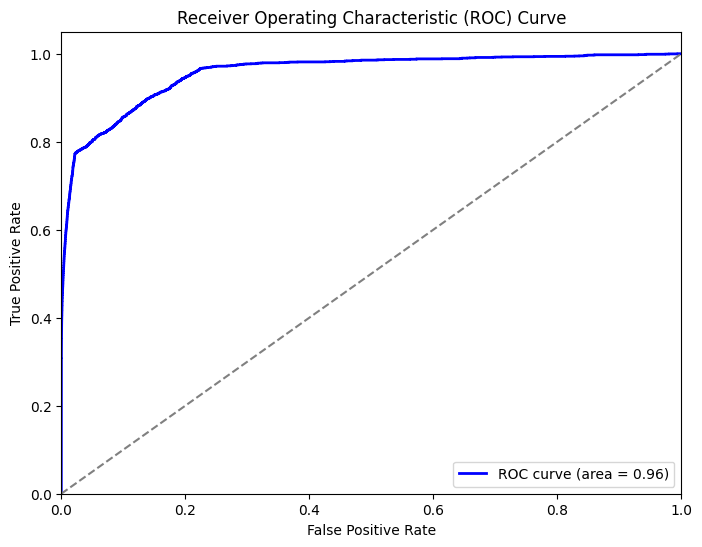

Optimal threshold (Youden's J): 0.3278
F1 Score at optimal threshold: 0.03740734793228476


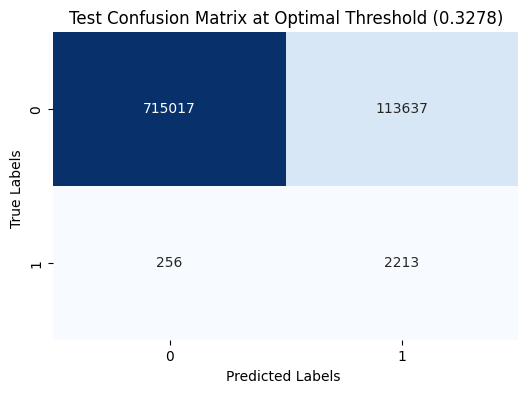

In [122]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
import numpy as np

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_smote)
roc_auc = roc_auc_score(y_test, y_test_prob_smote)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Find the optimal threshold using Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")

# Evaluate F1-score at this optimal threshold
y_test_pred_optimal = (y_test_prob_smote >= optimal_threshold).astype(int)
f1_test_optimal = f1_score(y_test, y_test_pred_optimal)
print("F1 Score at optimal threshold:", f1_test_optimal)

# Confusion matrix at optimal threshold
cm_test_optimal = confusion_matrix(y_test, y_test_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test_optimal, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(f"Test Confusion Matrix at Optimal Threshold ({optimal_threshold:.4f})")
plt.show()

In [130]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=21)

# Train the model on your training data
rf_model.fit(X_train_preprocessed,y_train)

# Make predictions on your testing data
y_test_pred_rf = rf_model.predict(X_test_preprocessed)

In [131]:
# Make predictions on your training data
y_train_pred_rf = rf_model.predict(X_train_preprocessed)
y_train_pred_rf
y_test_pred_rf

array([0, 0, 0, ..., 0, 0, 0])

In [132]:
from sklearn.metrics import f1_score
f1 = f1_score(y_train,y_train_pred_rf)
print("F1 Score of train data:", f1)

f2 = f1_score(y_test,y_test_pred_rf)
print("F1 Score of test data:", f2)

F1 Score of train data: 0.9999129450683382
F1 Score of test data: 0.8214879961968148


In [133]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_test_pred_rf)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828654
           1       0.99      0.70      0.82      2469

    accuracy                           1.00    831123
   macro avg       1.00      0.85      0.91    831123
weighted avg       1.00      1.00      1.00    831123



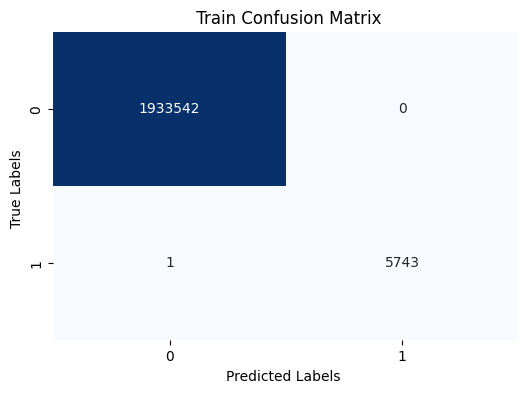

In [134]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_train_pred_rf)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Train Confusion Matrix")
plt.show()

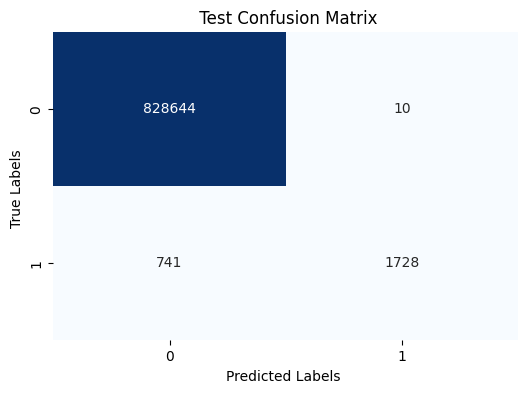

In [135]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_rf)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Test Confusion Matrix")
plt.show()

In [136]:
import xgboost as xgb

# Create an XGBoost classifier
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Train the model on your training data
xgb_model.fit(X_train_preprocessed,y_train)

# Make predictions on your testing data
y_test_pred_xgb = xgb_model.predict(X_test_preprocessed)

In [137]:
# Make predictions on your training data
y_train_pred_xgb = rf_model.predict(X_train_preprocessed)
y_train_pred_xgb
y_test_pred_xgb

array([0, 0, 0, ..., 0, 0, 0])

In [138]:
f1 = f1_score(y_train,y_train_pred_xgb)
print("F1 Score of train data:", f1)

f2 = f1_score(y_test,y_test_pred_xgb)
print("F1 Score of test data:", f2)

F1 Score of train data: 0.9999129450683382
F1 Score of test data: 0.7740029542097489


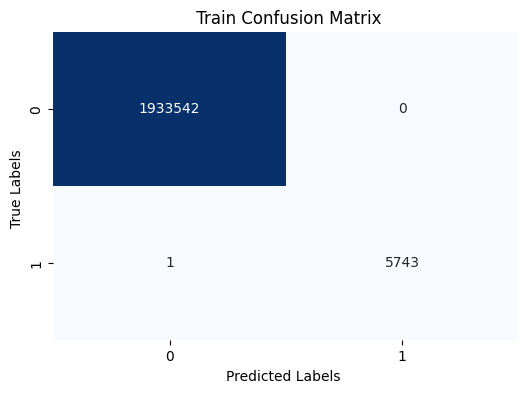

In [139]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_train_pred_xgb)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Train Confusion Matrix")
plt.show()

In [140]:
import pandas as pd
import numpy as np

# 1. Örnek sentetik veri oluşturma (Eğitim verisiyle aynı sütunlar)
synthetic_data = pd.DataFrame({
    'type': ['TRANSFER', 'CASH_OUT', 'TRANSFER'],
    'amount': [50000.0, 1500.0, 1000000.0],
    'oldbalanceOrg': [60000.0, 2000.0, 1000000.0],
    'newbalanceOrig': [10000.0, 500.0, 0.0],
    'oldbalanceDest': [0.0, 10000.0, 0.0],
    'newbalanceDest': [50000.0, 11500.0, 0.0]
})

print("Sentetik Veri:")
print(synthetic_data)

# 2. Ön işleme boru hattını (pipeline) kullanarak veriyi hazırlama
# Not: final_pipeline değişkeninin tanımlı olduğu varsayılmaktadır.
synthetic_preprocessed = final_pipeline.transform(synthetic_data)

# 3. XGBoost modeli ile tahmin yapma
synthetic_predictions = xgb_model.predict(synthetic_preprocessed)
synthetic_probs = xgb_model.predict_proba(synthetic_preprocessed)[:, 1]

# Sonuçları yazdırma
synthetic_data['isFraud_Prediction'] = synthetic_predictions
synthetic_data['Fraud_Probability'] = synthetic_probs

print("\nTahmin Sonuçları:")
print(synthetic_data[['type', 'amount', 'isFraud_Prediction', 'Fraud_Probability']])

Sentetik Veri:
       type     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0  TRANSFER    50000.0        60000.0         10000.0             0.0   
1  CASH_OUT     1500.0         2000.0           500.0         10000.0   
2  TRANSFER  1000000.0      1000000.0             0.0             0.0   

   newbalanceDest  
0         50000.0  
1         11500.0  
2             0.0  

Tahmin Sonuçları:
       type     amount  isFraud_Prediction  Fraud_Probability
0  TRANSFER    50000.0                   0       8.218356e-09
1  CASH_OUT     1500.0                   0       2.313598e-08
2  TRANSFER  1000000.0                   1       1.000000e+00


In [141]:
# XGBoost modelini JSON formatında kaydet
xgb_model.save_model('/content/model_xgb.json')

print("Model başarıyla /content/model_xgb.json yoluna kaydedildi.")

Model başarıyla /content/model_xgb.json yoluna kaydedildi.


### Yerel Projede Modeli Kullanma Adımları

1.  **Gereksinimler:** Yerel terminalinizde `pip install xgboost pandas` komutuyla gerekli k7t7phaneleri kurun.
2.  **Modeli Y7kleme:** `xgb.XGBClassifier()` nesnesi oluŗturup `load_model()` metodunu kullanın.
3.  **Veri Hazırlama:** Tahmin yapılacak verinin, modelin eėitildiėi formatta (aynı s7tunlar ve aynı scaling/encoding iŗlemleri) olması ŗarttır.

In [142]:
import xgboost as xgb

# 1. Boŗ bir model nesnesi oluŗturun
local_model = xgb.XGBClassifier()

# 2. Kaydettiėiniz JSON dosyasını y7kleyin
local_model.load_model('model_xgb.json')

# 3. Yeni verilerle tahmin yapın
# Not: Veriler X_test_preprocessed ile aynı iŗlemlerden gemiŗ olmalıdır.
# predictions = local_model.predict(new_data_preprocessed)
print("Model baŗarıyla y7klendi ve kullanıma hazır!")

Model baŗarıyla y7klendi ve kullanıma hazır!


In [143]:
import pickle

# Pipeline nesnesini yerelde kullanmak üzere kaydet
with open('/content/full_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

print("Preprocessing pipeline başarıyla /content/full_pipeline.pkl yoluna kaydedildi.")

Preprocessing pipeline başarıyla /content/full_pipeline.pkl yoluna kaydedildi.
